<a href="https://colab.research.google.com/github/albert-magarire/Leetcode-Solutions/blob/java-dsa/Albert_Magarire_MATH_214.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Explained Variance Ratio by PCA components: [0.72962445 0.22850762]


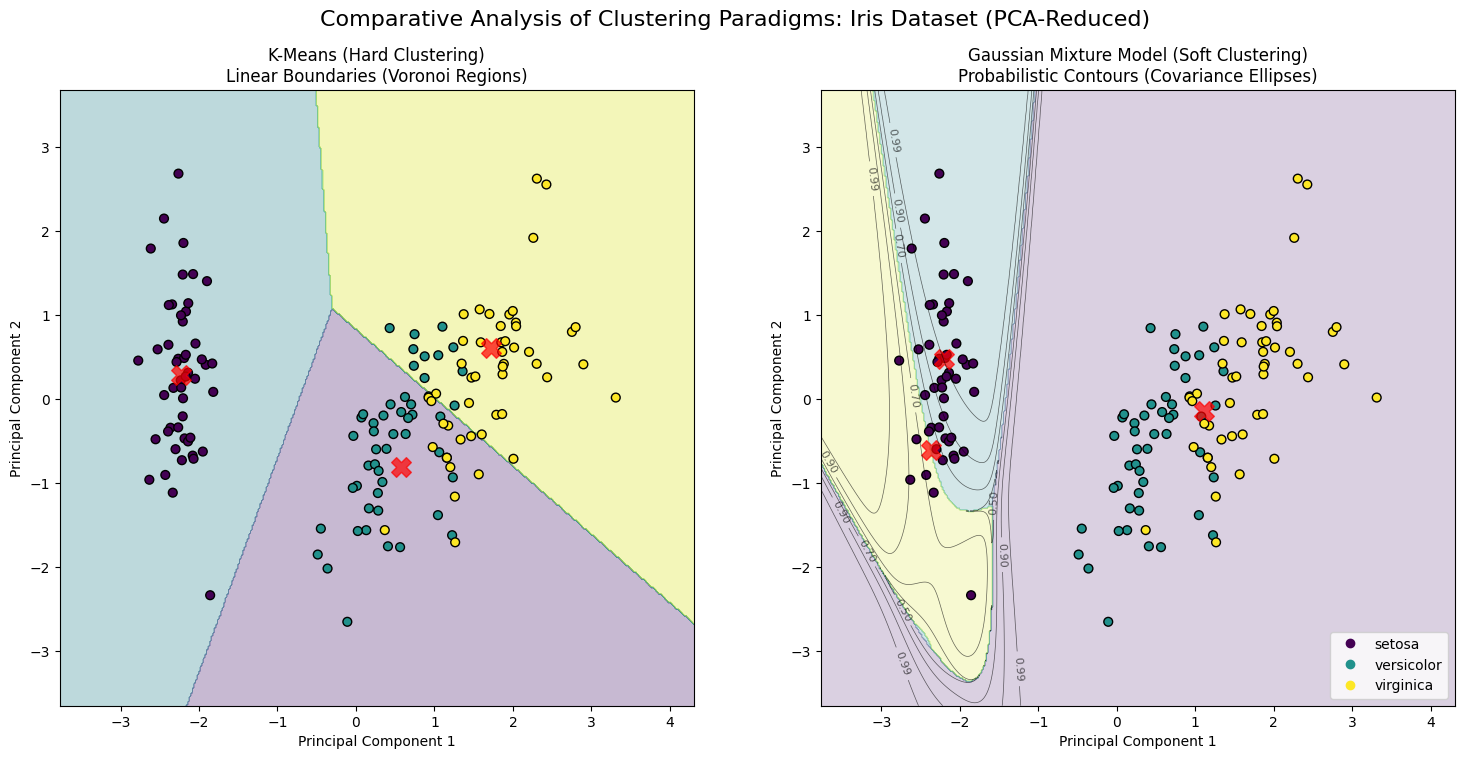


--- Reflection on Soft Clustering Probabilities (Sample Analysis) ---
Identifying ambiguous points where the model is uncertain (Max Prob < 0.75)...

Found 7 points with high uncertainty.
Index      Predicted       True Label      Probabilities (Cluster 0, 1, 2)
----------------------------------------------------------------------
2          versicolor      setosa          [0.00, 0.65, 0.35]
3          versicolor      setosa          [0.00, 0.63, 0.37]
6          versicolor      setosa          [0.00, 0.69, 0.31]
8          virginica       setosa          [0.00, 0.37, 0.63]
12         versicolor      setosa          [0.00, 0.67, 0.33]
38         virginica       setosa          [0.00, 0.32, 0.68]
47         versicolor      setosa          [0.00, 0.57, 0.43]

--- Code Execution Complete ---


In [2]:
# @title Comparative Analysis: GMM vs K-Means on Iris Dataset
# This code is designed for Google Colab.
# It handles data loading, model fitting (K-Means & GMM),
# and generates decision boundary and probability visualizations.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, LogNorm

# 1. Data Preparation & Preprocessing
def load_and_prep_data():
    """
    Loads Iris dataset, scales features, and reduces to 2D via PCA
    for visualization purposes.
    """
    # Load the classic Iris dataset
    iris = datasets.load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply PCA to reduce to 2 Dimensions for plotting
    # We use 2 components to capture maximum variance (approx 95%)
    # This allows us to plot valid 2D decision boundaries.
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    print(f"Explained Variance Ratio by PCA components: {pca.explained_variance_ratio_}")

    return X_pca, y, target_names

# 2. Visualization Functions
def plot_decision_boundaries(X, model, title, ax, is_gmm=False):
    """
    Plots decision boundaries on the provided axes.
    For K-Means: Plots hard boundaries using solid colors.
    For GMM: Plots soft probability contours and gradients.
    """
    # Create a meshgrid to plot the decision boundaries
    # We define a grid covering the feature space with some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    if is_gmm:
        # 1. Get Probabilities (Soft Assignments)
        probs = model.predict_proba(grid_points)
        labels = model.predict(grid_points)

        # 2. Map max probability to an array for contour plotting
        max_probs = np.max(probs, axis=1)
        Z_labels = labels.reshape(xx.shape)
        Z_probs = max_probs.reshape(xx.shape)

        # 3. Plot the 'Hard' boundary regions first (faintly)
        ax.contourf(xx, yy, Z_labels, alpha=0.2, cmap='viridis')

        # 4. Overlay Probability Gradients (Contours)
        CS = ax.contour(xx, yy, Z_probs, levels=[0.5, 0.7, 0.9, 0.99],
                        colors='k', linewidths=0.5, alpha=0.6)
        ax.clabel(CS, inline=True, fontsize=8, fmt='%.2f')

    else:
        # --- K-Means Hard Clustering Visualization ---
        Z = model.predict(grid_points)
        Z = Z.reshape(xx.shape)

        # Plot the hard regions
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Plot the actual data points
    # We color them by the GROUND TRUTH (y_true) to see where the clustering succeeds/fails
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, s=40, edgecolor='k', cmap='viridis')

    # Plot Centroids (if available)
    if hasattr(model, 'cluster_centers_'):
        centers = model.cluster_centers_
        ax.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroids')
    elif hasattr(model, 'means_'):
        means = model.means_
        ax.scatter(means[:, 0], means[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Means')

    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    return scatter

# 3. Execution Main Block
# Load data
X_pca, y_true, target_names = load_and_prep_data()

# Define parameters
n_clusters = 3

# --- K-Means (Hard Clustering) ---
# init='k-means++' ensures better starting centroids
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(X_pca)

# --- GMM (Soft Clustering) ---
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(X_pca)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot K-Means
scatter_kmeans_plot = plot_decision_boundaries(X_pca, kmeans,
                         "K-Means (Hard Clustering)\nLinear Boundaries (Voronoi Regions)",
                         ax1, is_gmm=False)

# Plot GMM
plot_decision_boundaries(X_pca, gmm,
                         "Gaussian Mixture Model (Soft Clustering)\nProbabilistic Contours (Covariance Ellipses)",
                         ax2, is_gmm=True)

plt.suptitle("Comparative Analysis of Clustering Paradigms: Iris Dataset (PCA-Reduced)", fontsize=16)
# Use the captured scatter plot object to get legend elements
handles, _ = scatter_kmeans_plot.legend_elements()
plt.legend(handles=handles, labels=list(target_names), loc='lower right')
plt.show()

# 4. Probability Assignments Inspection
print("\n--- Reflection on Soft Clustering Probabilities (Sample Analysis) ---")
print("Identifying ambiguous points where the model is uncertain (Max Prob < 0.75)...")

# Get probabilities for all points
probs = gmm.predict_proba(X_pca)
max_probs = np.max(probs, axis=1)
predicted_labels = gmm.predict(X_pca)

# Find indices of uncertain points
uncertain_indices = np.where(max_probs < 0.75)

if len(uncertain_indices) > 0:
    print(f"\nFound {len(uncertain_indices[0])} points with high uncertainty.")
    print(f"{'Index':<10} {'Predicted':<15} {'True Label':<15} {'Probabilities (Cluster 0, 1, 2)'}")
    print("-" * 70)
    # Iterate through the actual indices, not the numpy array object
    for idx in uncertain_indices[0]:
        p = probs[idx]
        pred_label = target_names[predicted_labels[idx]]
        true_label = target_names[y_true[idx]]
        print(f"{idx:<10} {pred_label:<15} {true_label:<15} [{p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f}]") # Print individual probabilities
else:
    print("No points found below the uncertainty threshold. The clusters are well-separated in this projection.")

print("\n--- Code Execution Complete ---")

### Reflection on Soft Clustering Benefits

Gaussian Mixture Models (GMMs) offer several advantages over hard clustering methods like K-Means, particularly in scenarios where clusters are not perfectly separated or have varying densities and shapes. These benefits are evident in the comparative analysis:

1.  **Probabilistic Assignments**: Unlike K-Means, which assigns each data point to a single cluster (a 'hard' assignment), GMMs provide a probability distribution for each point belonging to every cluster (a 'soft' assignment). This is crucial for understanding the uncertainty of a data point's membership. For instance, points located at the boundaries between clusters will have moderate probabilities for multiple clusters, indicating ambiguity, as shown in the "Probability Assignments Inspection" section above.

2.  **Modeling Complex Cluster Shapes**: GMMs can model clusters with elliptical shapes and varying orientations due to their use of covariance matrices (especially `covariance_type='full'`). K-Means, on the other hand, implicitly assumes spherical clusters of equal size, as it minimizes the sum of squared distances to centroids. The GMM plot clearly shows elliptical probabilistic contours, which better capture the natural structure of many real-world datasets, including the Iris dataset where species tend to have overlapping, non-spherical distributions in lower dimensions.

3.  **Handling Overlapping Clusters**: When clusters overlap, hard assignments can be misleading. GMM's probabilistic approach allows it to acknowledge the overlap and quantify the likelihood of a point belonging to each overlapping cluster. This provides a more nuanced and realistic representation of the underlying data structure.

4.  **Anomaly Detection**: Points with low maximum probability across all clusters can be identified as potential outliers or anomalies, as the model is not confident in assigning them to any particular cluster. This property can be leveraged for anomaly detection tasks.

In summary, while K-Means provides a straightforward and computationally efficient way to partition data, GMMs offer a richer, more flexible, and probabilistically-grounded approach to clustering, yielding more informative results, especially for complex datasets with overlapping or non-spherical clusters.